## Validation figures for holimocks ACM measurements

<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2156125/3951158030.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(k, k * poles[i], label=f'$\ell={ell}$')


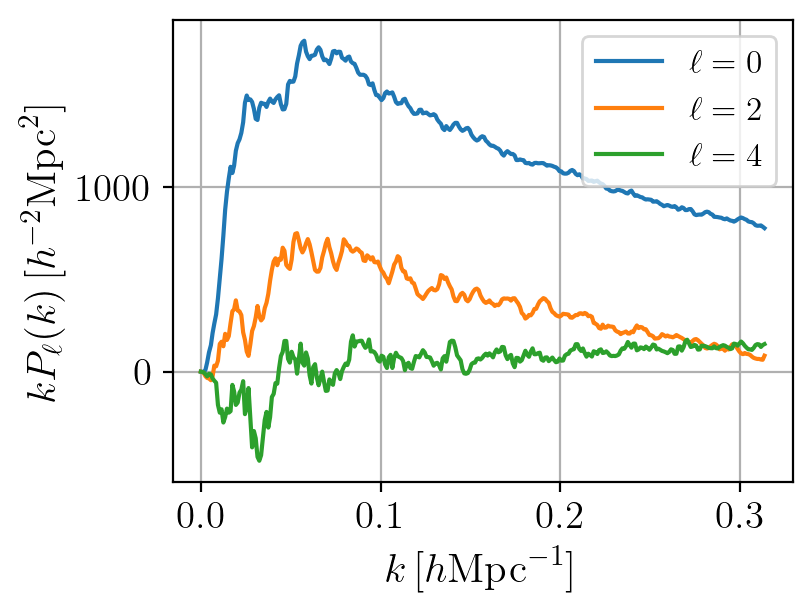

In [12]:
from typing import Optional
from jaxpower import read
from pathlib import Path
import matplotlib.pyplot as plt
from acm.utils.plotting import set_plot_style
%config InlineBackend.figure_format='retina'

def get_spectrum_fn(tracer='LRG', region='NGC', zmin=0.4, zmax=0.6, phase='201'):
    base_dir = Path(f'/global/cfs/cdirs/desicollab/users/epaillas/acm/dr2/measurements/holi/spectrum/ph{phase}')
    return base_dir / f'mesh2_poles_{tracer}_{region}_z{zmin}-{zmax}.h5'
                    
def get_multipoles(filename, kmin: Optional[float] = None, kmax: Optional[float] = None, rebin: int = 1):
    spectrum = read(filename)
    spectrum = spectrum.select(k=slice(0, None, rebin))
    poles = [spectrum.get(ell) for ell in spectrum.ells]
    k = poles[0].coords('k')
    poles = [pole.value() for pole in poles]
    return k, poles

@set_plot_style
def plot_multipoles(spectrum, ells=(0, 2, 4)):
    k, poles = get_multipoles(spectrum)
    fig, ax = plt.subplots(figsize=(4, 3))
    for i, ell in enumerate(ells):
        ax.plot(k, k * poles[i], label=f'$\ell={ell}$')
    ax.legend(fontsize=12)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel(r'$k\, [h {\rm Mpc}^{-1}$]', fontsize=15)
    ax.set_ylabel(r'$k P_\ell(k)\, [h^{-2}{\rm Mpc}^2]$', fontsize=15)
    return fig

if __name__ == '__main__':
    spectrum_fn = get_spectrum_fn(tracer='LRG', region='NGC', zmin=0.4, zmax=0.6, phase='201')
    fig = plot_multipoles(spectrum_fn)
    fig.show()